In [ ]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("scales")
install.packages("lubridate")
install.packages("stringr")

library(dplyr)
library(ggplot2)
library(scales)
library(lubridate)
library(stringr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [22]:
BASE <- "/content/northstar_data/northstar_dataset/"

orders <- read.csv(paste0(BASE, "orders.csv"))
deliveries <- read.csv(paste0(BASE, "deliveries.csv"))
customers <- read.csv(paste0(BASE, "customers.csv"))
drivers <- read.csv(paste0(BASE, "drivers.csv"))
vehicles <- read.csv(paste0(BASE, "vehicles.csv"))
hubs <- read.csv(paste0(BASE, "hubs.csv"))
incidents <- read.csv(paste0(BASE, "incidents.csv"))
complaints <- read.csv(paste0(BASE, "complaints.csv"))
app_events <- read.csv(paste0(BASE, "app_events.csv"))

In [21]:
# DATA CLEANING
# 1. STANDARDISE ZONE NAMES

standardise_zone <- function(x) {
  str_to_title(trimws(x))
}

orders$pickup_zone <- standardise_zone(orders$pickup_zone)
orders$dropoff_zone <- standardise_zone(orders$dropoff_zone)

customers$home_zone <- standardise_zone(customers$home_zone)

drivers$base_zone <- standardise_zone(drivers$base_zone)

vehicles$assigned_zone <- standardise_zone(
  vehicles$assigned_zone
)

app_events$zone_context <- standardise_zone(
  app_events$zone_context
)


# 2. CLEAN HUB IDS
deliveries$hub_id <- toupper(
  trimws(deliveries$hub_id)
)

# 3. PARSE DATE COLUMNS
complaints$created_at <- as.Date(
  complaints$created_at
)

# REMOVE NEGATIVE DISTANCE VALUES
deliveries <- deliveries %>%
  filter(route_distance_km >= 0)


# CHECK MISSING VALUES
missing_values <- sapply(
  list(
    orders=orders,
    deliveries=deliveries,
    complaints=complaints
  ),
  function(df) sum(is.na(df))
)

print(missing_values)

    orders deliveries complaints 
         0         14         16 



INTERPRETATION:
This chart compares delivery outcomes across hubs.
Hubs with larger failed or late delivery proportions
may require operational improvements.


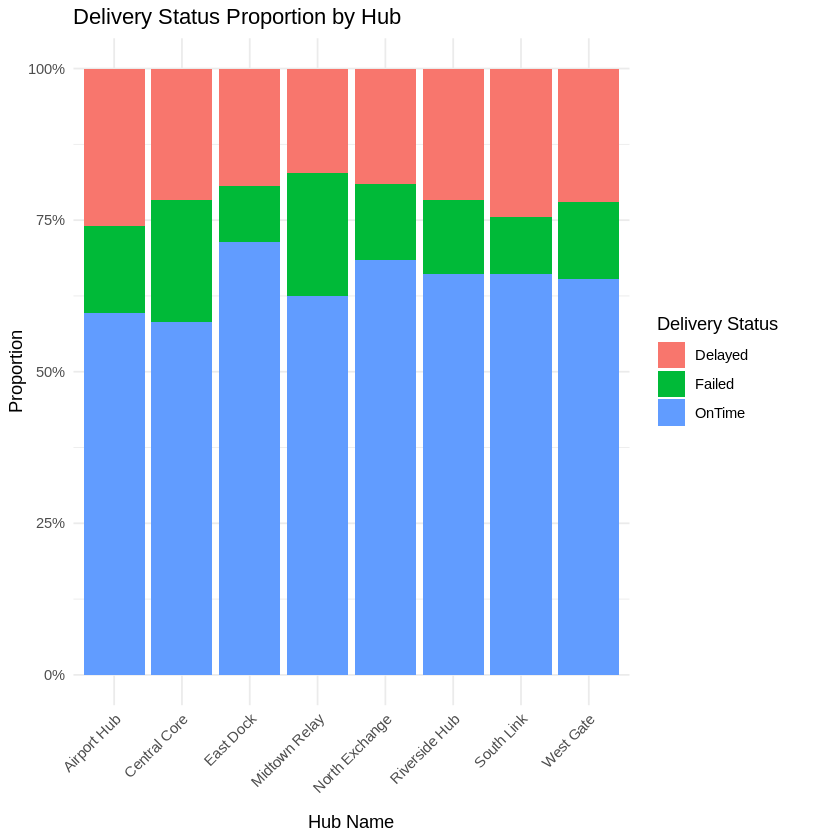

In [24]:
# CHART 1 - DELIVERY STATUS BY HUB

del_hub <- deliveries %>%
  left_join(hubs, by="hub_id") %>%
  filter(!is.na(delivery_status))

ggplot(del_hub,
       aes(x=hub_name,
           fill=delivery_status)) +

geom_bar(position="fill") +

scale_y_continuous(labels=percent) +

labs(
  title="Delivery Status Proportion by Hub",
  x="Hub Name",
  y="Proportion",
  fill="Delivery Status"
) +

theme_minimal() +

theme(
  axis.text.x = element_text(
    angle=45,
    hjust=1
  )
)

cat("
INTERPRETATION:
This chart compares delivery outcomes across hubs.
Hubs with larger failed or late delivery proportions
may require operational improvements.
")


INTERPRETATION:
Some zones show higher route override counts than others.
This may indicate route planning inefficiencies or difficult
road conditions in those regions.


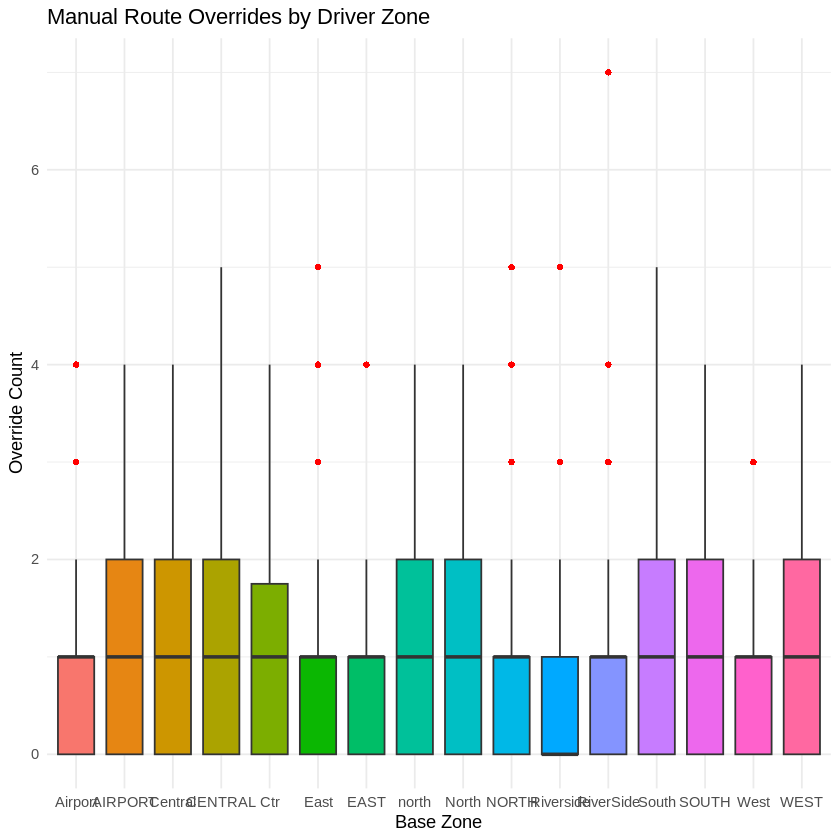

In [26]:
# CHART 2 - ROUTE OVERRIDE DISTRIBUTION

del_driver <- deliveries %>%
  left_join(drivers, by="driver_id")

ggplot(del_driver,
       aes(
         x=base_zone,
         y=manual_route_override_count,
         fill=base_zone
       )) +

geom_boxplot(
  outlier.color="red",
  outlier.shape=16
) +

labs(
  title= "Manual Route Overrides by Driver Zone",
  x="Base Zone",
  y="Override Count"
) +

theme_minimal() +

theme(
  legend.position="none"
)

cat("
INTERPRETATION:
Some zones show higher route override counts than others.
This may indicate route planning inefficiencies or difficult
road conditions in those regions.
")



INTERPRETATION:
Increasing complaint trends indicate worsening service quality.
High-severity complaints are particularly important because they
represent critical customer dissatisfaction.


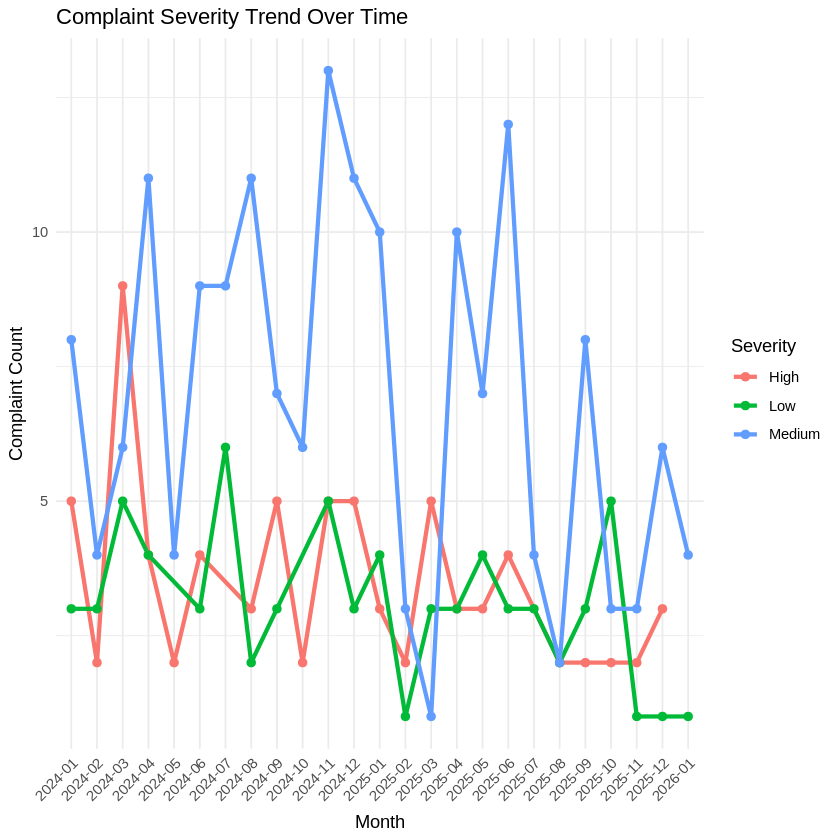

In [32]:
# CHART 3 — COMPLAINT SEVERITY OVER TIME


complaints$created_at <- lubridate::as_date(complaints$created_at)

complaints$month <- format(
  complaints$created_at,
  "%Y-%m"
)

complaint_trend <- complaints %>%
  group_by(month, severity) %>%
  summarise(
    total=n(),
    .groups="drop"
  )

ggplot(complaint_trend,
       aes(
         x=month,
         y=total,
         colour=severity,
         group=severity
       )) +

geom_line(size=1.2) +

geom_point(size=2) +

labs(
  title="Complaint Severity Trend Over Time",
  x="Month",
  y="Complaint Count",
  colour="Severity"
) +

theme_minimal() +

theme(
  axis.text.x = element_text(
    angle=45,
    hjust=1
  )
)

cat("
INTERPRETATION:
Increasing complaint trends indicate worsening service quality.
High-severity complaints are particularly important because they
represent critical customer dissatisfaction.
")

`geom_smooth()` using formula = 'y ~ x'



INTERPRETATION:
Poor vehicle battery health may contribute to lower customer
ratings due to delays or service interruptions.
The trend line helps identify this relationship.


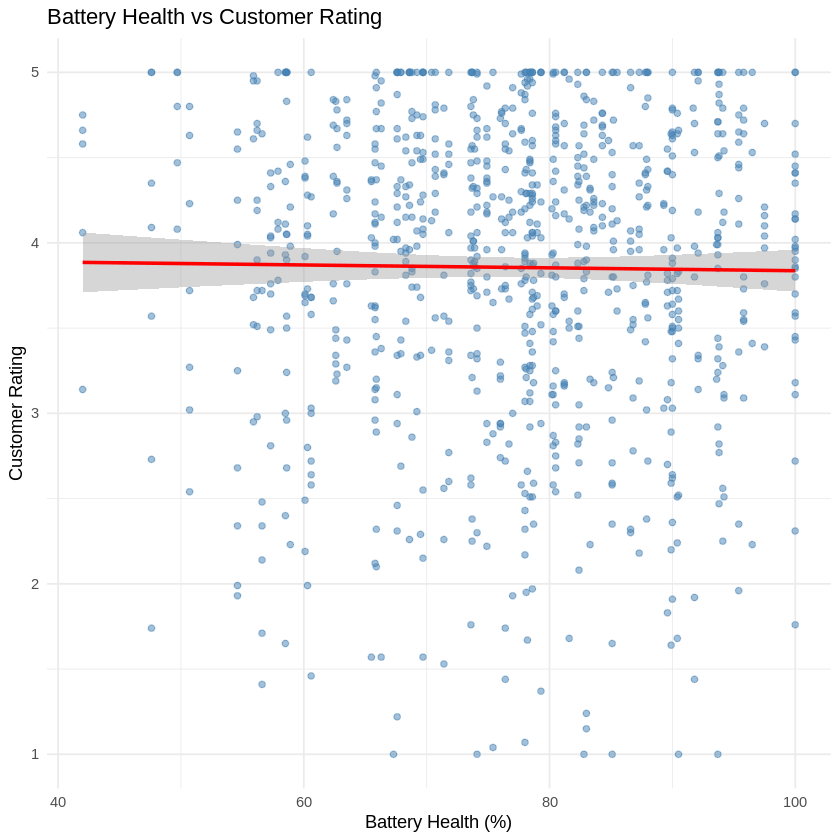

In [33]:
# CHART 4 — BATTERY HEALTH VS CUSTOMER RATING

del_veh <- deliveries %>%
  left_join(vehicles, by="vehicle_id") %>%
  filter(
    !is.na(battery_health_pct),
    !is.na(customer_rating_post_delivery)
  )

ggplot(del_veh,
       aes(
         x=battery_health_pct,
         y=customer_rating_post_delivery
       )) +

geom_point(
  alpha=0.5,
  colour="steelblue"
) +

geom_smooth(
  method="lm",
  colour="red",
  se=TRUE
) +

labs(
  title="Battery Health vs Customer Rating",
  x="Battery Health (%)",
  y="Customer Rating"
) +

theme_minimal()

cat("
INTERPRETATION:
Poor vehicle battery health may contribute to lower customer
ratings due to delays or service interruptions.
The trend line helps identify this relationship.
")


INTERPRETATION:
Different service types generate different order value ranges.
High-value service types may contribute more revenue but could
also involve higher operational costs.


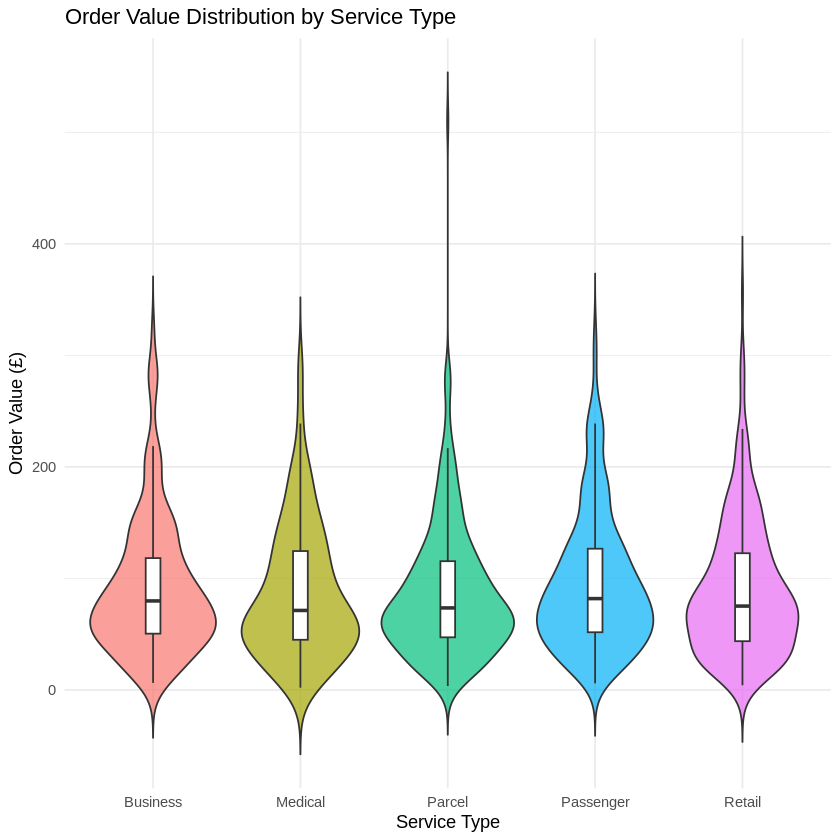

In [34]:
# CHART 5 — ORDER VALUE DISTRIBUTION

ggplot(orders,
       aes(
         x=service_type,
         y=order_value,
         fill=service_type
       )) +

geom_violin(
  trim=FALSE,
  alpha=0.7
) +

geom_boxplot(
  width=0.1,
  fill="white",
  outlier.shape=NA
) +

labs(
  title="Order Value Distribution by Service Type",
  x="Service Type",
  y="Order Value (£)"
) +

theme_minimal() +

theme(
  legend.position="none"
)

cat("
INTERPRETATION:
Different service types generate different order value ranges.
High-value service types may contribute more revenue but could
also involve higher operational costs.
")

In [35]:
# SUMMARY STATISTICS

summary_stats <- deliveries %>%
  summarise(
    mean_distance = mean(
      route_distance_km,
      na.rm=TRUE
    ),

    sd_distance = sd(
      route_distance_km,
      na.rm=TRUE
    ),

    mean_rating = mean(
      customer_rating_post_delivery,
      na.rm=TRUE
    ),

    mean_cost = mean(
      fuel_or_charge_cost,
      na.rm=TRUE
    ),

    total_overrides = sum(
      manual_route_override_count,
      na.rm=TRUE
    )
  )

print(summary_stats)

  mean_distance sd_distance mean_rating mean_cost total_overrides
1      13.90932    7.477907    3.864679  12.84129             921


In [38]:
# CORRELATION ANALYSIS

cor_matrix <- deliveries %>%
  select(
    route_distance_km,
    manual_route_override_count,
    customer_rating_post_delivery,
    fuel_or_charge_cost
  ) %>%
  na.omit() %>%
  cor()

print(round(cor_matrix, 3))

                              route_distance_km manual_route_override_count
route_distance_km                         1.000                       0.199
manual_route_override_count               0.199                       1.000
customer_rating_post_delivery             0.029                      -0.060
fuel_or_charge_cost                       0.527                       0.099
                              customer_rating_post_delivery fuel_or_charge_cost
route_distance_km                                     0.029               0.527
manual_route_override_count                          -0.060               0.099
customer_rating_post_delivery                         1.000              -0.059
fuel_or_charge_cost                                  -0.059               1.000


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded




INTERPRETATION:
The correlation matrix highlights relationships between delivery
distance, fuel cost, overrides, and customer ratings.
Strong positive or negative correlations may reveal operational
patterns affecting service quality.


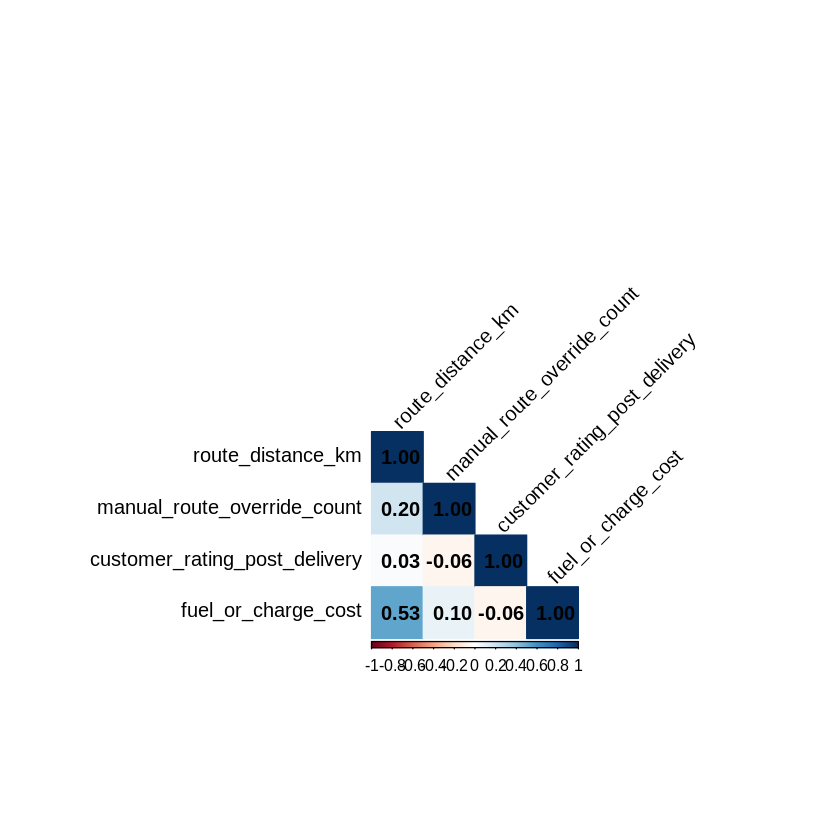

In [41]:
# CORRELATION HEATMAP

install.packages("corrplot")
library(corrplot)

corrplot(
  cor_matrix,
  method="color",
  type="lower",
  addCoef.col="black",
  tl.col="black",
  tl.srt=45
)

cat("
INTERPRETATION:
The correlation matrix highlights relationships between delivery
distance, fuel cost, overrides, and customer ratings.
Strong positive or negative correlations may reveal operational
patterns affecting service quality.
")